# [2주차] [5. ML] 과제
- **과제 목적**: Titanic 데이터 하나로 처음부터 ML의 과정을 끝까지 직접 밟아봅니다. 라이브러리 함수를 호출하는 데서 끝내지 않고, 학습의 핵심(loss, gradient descent)과 평가의 핵심(confusion matrix와 4대 지표)을 **손으로 직접 계산**해 개념을 체화합니다. 이어서 두 모델을 동일 조건에서 비교하고 성능 차이의 원인을 모델 구조 관점에서 해석합니다. 마지막 심화에서는 수업에서 그림으로만 본 overfitting을 실험으로 직접 재현합니다.

> ⚠️ **주의**: LLM를 써도 좋지만, **판단·검증·해석은 반드시 직접** 수행하고 사용 내역을 `## 3`에 기록하세요.


## 0. 환경 설정

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

MY_SEED = 42  # TODO: 랜덤한 숫자
np.random.seed(MY_SEED)

#  Titanic 데이터를 사용
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. 필수 과제

### 1-1. ML 문제 정의 (수업 §2)

코드를 짜기 전에, 이 문제를 ML 문제로 **정식화**합니다. 아래 빈칸을 채우세요.

- 우리는 이 데이터셋에서 타이타닉 탑승자의 생존 여부를 맞춰야합니다. **target(label)**은 어떤 column인가? → `survived`
- 이 데이터에는 label이 있다. 따라서 학습 방식은 지도학습이다.
- target이 범주형 이므로, 이 문제는 분류 문제다. → 정답: 분류
- 학습 전에 데이터를 train/test로 나누는 이유를 **본인의 언어로** 한 문장: "학습에 안 쓰인 데이터(=test data)에서도 모델이 생존 여부를 잘 예측하는지 평가하기 위해서이다."


### 1-2. 전처리와 데이터 분할

아래 TODO를 채우고, **각 주석의 빈칸에 '왜 이 단계가 필요한지'를 직접 적으세요.


In [24]:
# 사용할 feature와 target 선택
features = ["pclass", "sex", "age", "fare"]
target = "survived"

df = titanic[features + [target]].copy()

# [빈칸] age의 결측치를 중앙값으로 채우는 이유 (평균이 아니라 중앙값을 쓰는 이유 포함): 중앙값이 평균보다 이상치의 영향을 덜 받기 때문이다.
df["age"] = df["age"].fillna(df["age"].median())

# [빈칸] sex를 0/1 숫자로 바꾸는 이유 (모델 입장에서 설명): 모델이 문자열을 직접 처리할 수 없기 때문이다.
df["sex"] = (df["sex"] == "female").astype(int)

df = df.dropna()

X = df[features]
y = df[target]

# TODO: train/test를 8:2로 분할하세요. random_state=MY_SEED 사용
# [빈칸] stratify=y 옵션을 주는 이유: target인 y의 비율을 동일하게 유지하기 위해서이다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=MY_SEED,
    stratify=y
)

print(f"train: {X_train.shape}, test: {X_test.shape}")
print(f"train 생존율: {y_train.mean():.3f}, test 생존율: {y_test.mean():.3f}")

train: (712, 4), test: (179, 4)
train 생존율: 0.383, test 생존율: 0.385


### 1-3. Gradient Descent 손계산 (수업 §3)

수업에서 "학습 = loss를 낮추는 방향으로 파라미터를 조금씩 갱신"이라고 했습니다. 이걸 **가장 작은 예제로 직접 계산**합니다.

**설정**: 데이터 3개 $(x, y) = (1,2), (2,4), (3,6)$, 모델 $\hat{y} = wx$ (절편 없음), loss는 MSE

$$L(w) = \frac{1}{3}\sum_{i=1}^{3}(y_i - wx_i)^2, \qquad \frac{\partial L}{\partial w} = -\frac{2}{3}\sum_{i=1}^{3} x_i(y_i - wx_i)$$

**문제**: $w_0 = 0$, learning rate $\eta = 0.1$에서 시작하여 **gradient descent를 3회 반복해 직접 계산**하고, **각 단계에서 $w$가 왜 그 방향으로, 왜 그만큼 움직였는지** 설명하세요. (계산기는 써도 되지만 코드로 먼저 답을 구하면 안 됩니다 — 아래 검증 셀은 손계산이 끝난 뒤에 실행)

| 반복 | 현재 $w$ | 각 데이터의 오차 $(y_i - wx_i)$ | gradient $\frac{\partial L}{\partial w}$ | 갱신된 $w$ |
|---|---|---|---|---|
| 1 | 0 | 2, 4, 6 | -56/3(=-18.6667) | 1.8667 |
| 2 | 1.8667 | 0.1333, 0.2667, 0.4 | -1.2444 | 1.9911 |
| 3 | 1.9911 | 0.0089, 0.0178, 0.0267 | -0.0830 | 1.9994 |

**서술**: 매 반복마다 gradient의 크기가 어떻게 변했고, 그것이 $w$의 이동량과 어떤 관계인가? 이 과정이 언제, 왜 멈추게 될까? → `매 반복마다 gradient의 크기는 18.6667 -> 1.2444 -> 0.0830으로 점점 작아졌고 w의 이동량도 1.8667 -> 0.1244 -> 0.0083으로 함께 작아졌다. 이는 w가 최적값에 가까울수록 loss의 기울기가 작아지기 때문이다. 그러다가 최적값에 충분히 가까워져 gradient가 0에 매우 가까워지면 w가 거의 변하지 않아 학습이 수렴해 멈추게 된다.`


In [25]:
# ===== 손계산 검증용 셀 (표를 다 채운 뒤에 실행하세요) =====
# 주의: 위에서 만든 target y(Series)를 덮어쓰지 않도록 여기서는 gx, gy 라는 별도 변수를 쓴다.
gx = np.array([1, 2, 3])
gy = np.array([2, 4, 6])

w = 0.0
lr = 0.1

for step in range(1, 4):
    # TODO: 위 수식대로 gradient를 코드로 옮기세요
    grad = -2/len(gx) * np.sum(gx * (gy - w * gx))   # 힌트: -2/len(gx) * np.sum(...)

    # [빈칸] gradient의 '반대 방향'으로 이동하는 이유: loss를 감소시키는 방향으로 parameter를 업데이트하기 위해서이다.
    w = w - lr * grad

    loss = np.mean((gy - w * gx) ** 2)
    print(f"step {step}: grad = {grad:+.4f}, w = {w:.4f}, loss = {loss:.4f}")

# 손계산 결과와 출력이 일치하는지 확인하고, 다르면 어디서 틀렸는지 찾아 적으세요: 일치합니다.

step 1: grad = -18.6667, w = 1.8667, loss = 0.0830
step 2: grad = -1.2444, w = 1.9911, loss = 0.0004
step 3: grad = -0.0830, w = 1.9994, loss = 0.0000


### 1-4. 두 모델 학습과 비교

수업에서 "모든 알고리즘은 (f의 형태 / loss / 찾는 방법)에 대한 서로 다른 답"이라고 했습니다. 형태가 전혀 다른 두 모델을 **같은 데이터, 같은 조건**에서 학습시켜 비교합니다.

- **모델 A**: Logistic Regression (선형 + sigmoid)
- **모델 B**: Decision Tree (재귀 분할)


In [26]:
# 과정 확인 장치: train과 test 성능을 모두 기록합니다
results = {}

# TODO: 모델 A — LogisticRegression을 학습시키세요 (max_iter=1000)
model_a = LogisticRegression(max_iter=1000)
model_a.fit(X_train, y_train)

# TODO: 모델 B — DecisionTreeClassifier를 학습시키세요 (random_state=MY_SEED)
model_b = DecisionTreeClassifier(random_state=MY_SEED)
model_b.fit(X_train, y_train)

for name, model in [("Logistic Regression", model_a), ("Decision Tree", model_b)]:
    # [빈칸] train 정확도와 test 정확도를 '둘 다' 기록하는 이유 (수업 §3의 개념과 연결해서): train, test의 정확도를 비교해서 모델이 학습 데이터에 과적합(overfitting)되었는지 확인하기 위해서이다.
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = (train_acc, test_acc)
    print(f"{name:20s} | train acc: {train_acc:.4f} | test acc: {test_acc:.4f}")

Logistic Regression  | train acc: 0.7992 | test acc: 0.7877
Decision Tree        | train acc: 0.9803 | test acc: 0.8101


### 1-5. 평가지표 직접 유도

수업에서 "Confusion Matrix 하나에서 4개 지표가 전부 유도된다"고 했습니다. **sklearn의 지표 함수를 쓰기 전에**, TP/TN/FP/FN으로부터 직접 계산해 봅니다. (모델 A 기준)


In [27]:
y_pred = model_a.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# sklearn의 confusion_matrix 배치: [[TN, FP], [FN, TP]]
TN, FP = cm[0]
FN, TP = cm[1]
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")

# TODO: 아래 4개 지표를 TP/TN/FP/FN '만으로' 직접 계산하세요 (sklearn 함수 사용 금지)
my_accuracy  = (TP + TN) / (TP + TN + FP + FN)
my_precision = TP / (TP + FP)   # [빈칸] precision의 분모에 들어가는 것과 그 의미: TP + FP, 모델이 Positive라고 예측한 전체 개수를 의미합니다.
my_recall    = TP / (TP + FN)   # [빈칸] recall의 분모에 들어가는 것과 그 의미: TP + FN, 실제 Positive인 개수를 의미합니다.
my_f1        = 2 * (my_precision * my_recall) / (my_precision + my_recall)   # 힌트: precision과 recall의 조화평균

# 검증: sklearn과 비교 (통과하지 못하면 수식을 다시 확인)
assert np.isclose(my_accuracy,  accuracy_score(y_test, y_pred))
assert np.isclose(my_precision, precision_score(y_test, y_pred))
assert np.isclose(my_recall,    recall_score(y_test, y_pred))
assert np.isclose(my_f1,        f1_score(y_test, y_pred))
print("✅ 4개 지표 모두 sklearn과 일치")

Confusion Matrix:
 [[94 16]
 [22 47]]
TP=47, TN=94, FP=16, FN=22
✅ 4개 지표 모두 sklearn과 일치


### 1-6. 결과 해석 (필수 서술)

아래 4개 질문에 **본인의 실험 결과 수치를 근거로** 답하세요. (수치 없이 일반론만 쓰면 감점)

1. **왜 이러한 결과가 나왔는가?** — 두 모델의 test 정확도는 각각 얼마였고, 이 데이터에서 그 정도 성능이 나온 이유를 feature 관점에서 추측하면? → `Logistic Regression의 test 정확도는 0.7877이고, Decision Tree의 test 정확도는 0.7765으로 비슷하게 나타났습니다. 이 데이터에서 사용한 feature은 pclass, sex, age, fare로 제한되어 있어 완전히 정확하게 설명하기는 어렵지만 성별이나 객실 등급처럼 생존과 관련이 있는 변수들이 포함되어 있기 때문에 약 0.78 정도의 정확도가 나온 것으로 추측할 수 있습니다.`
2. **두 모델의 성능 차이는 어디에서 발생했는가?** — train acc와 test acc의 '차이'가 두 모델에서 어떻게 달랐는가? 이를 모델 구조(선형 경계 vs 재귀 분할)의 관점에서 해석하면? → `Logistic Regression에서 train과 test의 정확도 차이는 0.0086이고, Decision Tree에서 train과 test의 정확도 차이는 0.2066로 큰 차이가 발생했습니다. 이는 Logistic Regression은 선형적인 decision boundary를 사용해서 단순하지만 Decision Tree는 데이터를 분기점에서 반복적으로 분할하면서 train 데이터에 더 세밀하게 맞출 수 있기 때문에 overfitting이 발생한 것 같습니다.`
3. **실험 조건을 변경하면 결과가 어떻게 달라지는가?** — `MY_SEED`를 다른 값으로 바꿔 1-2 ~ 1-4를 다시 실행해 보고, 어떤 수치가 얼마나 흔들렸는지 기록. 이 흔들림을 줄이는 방법으로 수업에서 배운 것은? → `먼저 MY_SEED를 42로 바꾸었을 때 Logistic Regression의 train 정확도는 0.7992이고, test 정확도는 0.7877이며 Decision Tree의 train 정확도는 0.9803이고, test 정확도는 0.8101입니다. 다른건 비슷하거나 변화가 없지만 Decision Tree에서의 test 정확도가 0.0336정도로 증가했으며, 이러한 한 번의 데이터 분할에 따른 성능의 흔들림을 줄이기 위해 Cross Validation을 사용할 수 있습니다. (강의자료 p.50)`
4. **예상과 다른 결과가 나왔다면 그 원인은 무엇인가?** — 과제를 시작하기 전 예상과 달랐던 지점 하나와, 그 원인에 대한 본인의 가설: → `처음에는 한 모델이 다른 모델보다 일관되게 높은 test 성능을 보일 것이라고 예상했지만 random seed를 바꾸니 두 모델의 성능 순위가 달라졌습니다. 처음에는 Logistic Regression의 test 정확도가 0.7877로 Decision Tree의 0.7765보다 높았지만, seed를 42로 변경한 후에는 Decision Tree가 0.8101로 Logistic Regression의 0.7877보다 높아졌습니다. 이는 아마 train/test 데이터가 어떻게 분할되는지에 따라 모델의 평가 결과가 달라질 수 있고 특히 Decision Treeu가 데이터 분할에 민감하다는 특징을 가지고 있기 때문이라고 생각합니다.`


## 2. 심화 과제 (선택)

### 2-1. Overfitting 직접 재현하기

 overfitting/underfitting curve를 **본인 데이터로 직접 그립니다.** Decision Tree의 `max_depth`를 1부터 15까지 바꿔가며 train/test 정확도를 기록하세요.


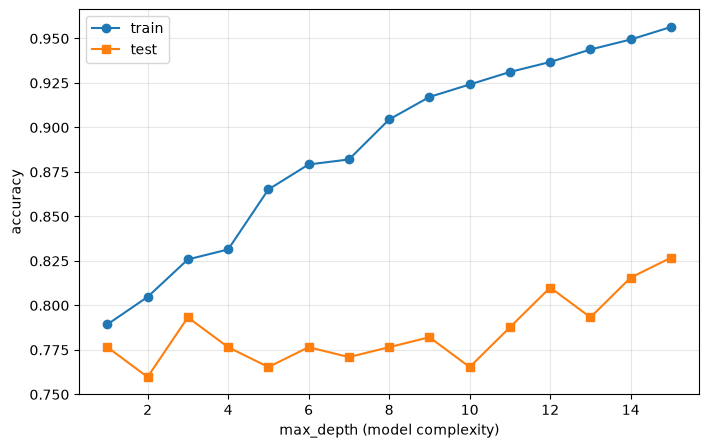

In [28]:
depths = range(1, 16)
train_scores, test_scores = [], []

for d in depths:
    # TODO: max_depth=d인 DecisionTreeClassifier를 학습시키고
    #       train/test 정확도를 각 리스트에 추가하세요
    model = DecisionTreeClassifier(max_depth=d, random_state=MY_SEED)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker="o", label="train")
plt.plot(depths, test_scores, marker="s", label="test")
# Colab 기본 환경엔 한글 폰트가 없어 제목/라벨은 영문으로 둔다(한글이면 □로 깨짐)
plt.xlabel("max_depth (model complexity)")
plt.ylabel("accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# 해석 (필수):
# - 그래프에서 underfitting 구간과 overfitting 구간은 각각 어디인가? → max_depth가 1-2 정도로 작을 땐 train, test의 정확도가 모두 낮에 underfitting으로 볼 수 있습니다. max_depth가 증가할수록 train 정확도는 계속 증가하지만 test 정확도는 그만큼 증가하지 않고 두 정확도의 차이가 커지므로 depth가 5 이상일 때부터 overfitting 경향이 나타납니다.
# - 본인 데이터 기준 최적의 max_depth와 그렇게 판단한 근거는? → 15, max_depth=15에서 가장 높은 정확도를 보였기 (test 정확도 기준) 때문입니다.
# - 이 그래프가 수업의 "train loss만 낮추는 건 쉽다"는 문장과 어떻게 연결되는가? → max_depth가 증가할수록 모델이 복잡해지니까 train 정확도는 계속 증가하지만 test 정화도는 계속 함께 증가하지는 않는걸 보아 복잡한 모델로 train 데이터에 잘 맞추어 train loss를 낮추는 것은 쉽지만 이게 새로운 test 데이터에서도 좋은 성능을 보장하지는 않는다는 것을 확인할 수 있습니다.

### 2-2. 비지도학습 미리보기 — label을 가리면 무엇이 보일까?

지금까지는 `survived`라는 label을 알고 학습했습니다(지도학습). 이번엔 **label을 일부러 가리고**, 데이터의 구조만으로 무엇이 보이는지 확인합니다.


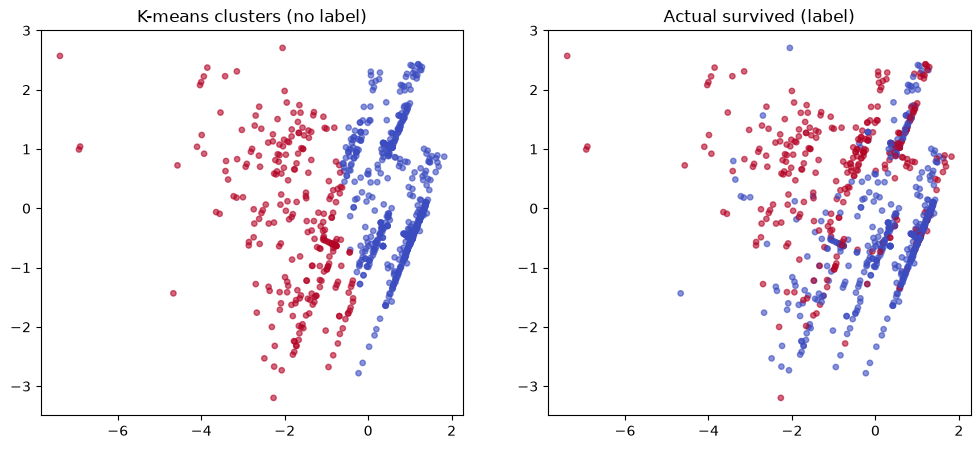

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# [빈칸] PCA/K-means 전에 스케일링이 필요한 이유 (fare와 age의 단위를 생각해 보세요): sex는 0 또는 1이고, pclass는 1, 2, 3이고 age는 수십 단위이고, fare은 수십~수백 단위이기 때문입니다. K-means와 PCA는 거리 기반 알고리즘이므로, feature의 단위가 다르면 특정 feature가 지나치게 영향을 미칠 수 있습니다.
X_scaled = StandardScaler().fit_transform(X)

# TODO: PCA로 2차원으로 축소하세요
X_2d = PCA(n_components=2).fit_transform(X_scaled)

# TODO: K-means로 2개 군집을 찾으세요 (random_state=MY_SEED, n_init=10)
clusters = KMeans(n_clusters=2, random_state=MY_SEED, n_init=10).fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="coolwarm", alpha=0.6, s=15)
axes[0].set_title("K-means clusters (no label)")
# ⚠️ c=y 로 넘기면 pandas Series를 단일 RGBA로 오해해 ValueError가 난다. 반드시 c=y.values
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y.values, cmap="coolwarm", alpha=0.6, s=15)
axes[1].set_title("Actual survived (label)")
plt.show()

# 해석 (필수):
# - K-means가 찾은 군집은 실제 생존 여부와 얼마나 겹치는가? → 약간 겹치는 부분이 있기는 하지만 완전히 겹치지는 않습니다. K-means 그래프에서는 두 cluster가 비교적 뚜렷하게 분리되었지만 실제 생존 여부 그래프에서는 같은 영역에서도 두 색깔이 일부 섞여 있는 것을 확인할 수 있습니다.
# - 겹친다면/겹치지 않는다면, 그 이유는 무엇이라고 생각하는가?
#   (힌트: K-means는 무엇을 기준으로 데이터를 나누는가?) → K-means는 실제 생존 label을 사용하지 않고 pclass, sex, age, fare과 같은 feature들의 거리 기반으로 군집을 나누기 때문에 실제 생존 여부와 완전히 일치하지 않을 수도 있습니다.

## 3. 생성형AI 활용 방법

문제를 풀면서 GPT, Claude 등 생성형 AI를 **어디에, 어떻게** 썼는지 기록하는 곳입니다. (사용하지 않았다면 "사용하지 않음"이라고 적으세요)

- **활용 방법**: 어떤 문제에서, 어떤 목적으로(개념 질문 / 에러 해결 / 코드 초안 등) 사용했는지 → 개념 질문(stratify), 코드 검토(PCA)
- **AI 답변 중 그대로 쓰지 않고 직접 수정·검증한 부분**: → `개념 질문(stratify)은 AI 답변을 정리하여 "target인 y의 비율을 동일하게 유지하기 위해서이다."라고 답안을 작성했으며, 코드 검토는 확인 후 코드를 확정지었습니다.`
- **대화 내역 붙여넣기**: (아래에 전체 대화를 붙여넣으세요)

```
1. 개념 질문 (stratify)
"stratify"는 주로 scikit-learn의 `train_test_split` 함수에서 쓰이는 파라미터예요. 데이터를 훈련용/테스트용으로 나눌 때, **각 클래스(레이블)의 비율을 원본 데이터와 동일하게 유지**하면서 분할하도록 해줍니다.

## 왜 필요할까?

예를 들어 이진 분류 문제에서 전체 데이터의 클래스 비율이 90:10이라고 해봐요. 그냥 랜덤하게 나누면 운이 나쁠 경우 훈련셋은 95:5, 테스트셋은 70:30 이런 식으로 비율이 틀어질 수 있어요. 특히 데이터가 적거나 클래스 불균형이 심할 때 이런 문제가 자주 생깁니다.

`stratify`를 쓰면 이런 왜곡을 막아줍니다.

## 사용 예시

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y,  # y의 클래스 비율을 유지하며 분할
    random_state=42
)
```

`stratify=y`로 설정하면, y(레이블)에 있는 각 클래스의 비율이 train과 test 셋에서 동일하게 유지돼요.

## 언제 쓰면 좋을까?

- **분류(classification) 문제**에서 특히 유용해요 (회귀에는 보통 안 씀)
- **클래스 불균형**이 있을 때 (예: 사기 탐지, 희귀 질병 진단 등)
- **데이터셋이 작을 때** — 데이터가 적을수록 랜덤 분할의 편차가 커지니까요

## 주의할 점

- `stratify`에는 보통 레이블 배열(`y`)을 넣지만, 다른 범주형 변수를 기준으로 층화하고 싶다면 그 컬럼을 넣어도 돼요
- 회귀(연속값 예측)에서는 기본적으로 지원 안 하지만, 연속값을 구간별로 나눠서(binning) 우회적으로 쓰기도 해요

혹시 특정 상황(예: 다중 클래스, 회귀 문제)에서 어떻게 적용하는지 궁금하신가요?



2. 코드 검토 (PCA)
네, 둘 다 맞게 작성하셨어요.

- `PCA(n_components=2).fit_transform(X_scaled)` — 2차원 축소 정확
- `KMeans(n_clusters=2, random_state=MY_SEED, n_init=10).fit_predict(X_scaled)` — 군집 2개, 시드/n_init 옵션 모두 정확

둘 다 스케일링된 `X_scaled`를 입력으로 쓴 것도 맞습니다.
```


## 4. 회고

- **가장 어려웠던 부분**과 그것을 어떻게 해결했는지 (또는 아직 해결하지 못했는지, 없다면 없음이라고 적어도 됨): → `없음`
- 이번 과제 내용 중 기술블로그 '과제 복습' 섹션에 정리할 핵심 1가지: → `2-1에서 max_depth를 바꿔가며 train/test 정확도를 비교한 코드`
